# YOLO + Qwen3-VL — 스마트팜 딸기 병해충 피해 분석 - Colab 용

[AI Hub 지능형 스마트팜(오이, 딸기)](https://aihub.or.kr/aihubdata/data/view.do?dataSetSn=71523)의 **딸기 전용 병해충 세트**(`지능형 스마트팜 딸기 데이터`)를 이용해  
**YOLO 객체 탐지 → 탐지 결과 시각화 → Qwen3-VL 장면 설명 → 구조화된 병해 위험 분석(JSON)** 파이프라인을 실행하는 예제입니다.

공식 분할은 **Training 7,466장 + Validation 933장**이며, **잿빛곰팡이병 / 흰가루병**, **열매 / 잎**이 포함됩니다.  
라벨 bbox 중 **큰 박스 = `plant`**, **나머지 = `gray_mold` 또는 `powdery_mildew`** 로 매핑합니다.

| 단계 | 내용 |
|------|------|
| 1 | 딸기 병해충 공식 train/val 변환 (`plant` / `gray_mold` / `powdery_mildew`) |
| 2 | YOLO26s 학습(또는 기존 가중치 로드) → 과실·잎 / 병반 탐지 |
| 3 | 탐지 bbox 시각화 |
| 4 | Qwen3-VL-4B로 스마트팜 장면 설명 |
| 5 | Qwen3-VL + YOLO 공간 관계 → **병해 위험 분석 JSON** 출력 |

---

## QLoRA 파인튜닝 개요 (§10)

이 노트북 후반(§10)에서는 **Qwen3-VL-4B-Instruct**를 **4bit QLoRA**로 스마트팜 딸기 병해 도메인에 맞게 미세조정합니다.

### QLoRA란?

| 개념 | 설명 |
|------|------|
| **LoRA** | 거대 LLM 전체를 학습하지 않고, attention 등 일부 레이어에 **저랭크 어댑터**만 추가해 학습 |
| **QLoRA** | 베이스 모델을 **4bit 양자화(NF4)** 로 GPU에 올린 뒤 LoRA만 학습 → 12GB VRAM에서 VLM SFT 가능 |
| **SFT** | Supervised Fine-Tuning. (이미지, 질문) → (정답) 쌍으로 지도학습 |

### 본 노트북의 파인튜닝 전략

1. **Teacher Answer 자동 생성**: 라벨 JSON의 bbox·메타(`작물상태코드`, `피해정도코드`)로 위험도·JSON 정답을 규칙 기반 생성
2. **2종 태스크**: ① 병해 위험 JSON 출력  ② 스마트팜 장면 한국어 설명 (잿빛/흰가루 균등 샘플 × 2)
3. **Vision encoder 동결**: `freeze_vision_modules()` — LoRA는 LLM `q_proj`, `v_proj`만 학습
4. **VRAM 절약**: `max_pixels=256×28×28`, batch=1, gradient_accumulation=4, 4bit + gradient checkpointing

### 실행 경로 (추천)

| 목적 | 실행 범위 | 소요 (RTX 3060 12GB) |
|------|-----------|----------------------|
| 추론 파이프라인만 | §0 → §1~§8 | YOLO 전체 학습 약 1.5~2시간, Qwen3 추론 +수분 |
| QLoRA 학습 포함 | §0 → §10-4 | 학습 약 20~25분 추가 |
| 학습 생략·추론만 | 커널 재시작 → §0 → §10-1 → §10-5 | 어댑터 이미 있을 때 |

<br>

> **관련 노트북**: `11_yolo_qwen3_smart_factory_accident_analysis.ipynb` (공장 사고 분석 원본) · `07_qwen3_vl_qlora_mini_train.ipynb` · `08_qwen3_vl_qlora_fine_tuning.ipynb`

> 선행 참고: `06_qwen3_vl_example.ipynb`



## 0. 환경 설정

```bash
pip install -r requirements.txt
pip install ultralytics opencv-python-headless
```

| 패키지 | 용도 |
|--------|------|
| `ultralytics` | YOLO26 탐지·학습 |
| `transformers>=4.57.0` | Qwen3-VL |
| `opencv-python-headless` | bbox 시각화 |

<br>

> **VRAM 안내 (RTX 3060 12GB)**: YOLO 학습/추론 후 Qwen3-VL 로드 전 `torch.cuda.empty_cache()`로 GPU 메모리를 비웁니다.
> Qwen3-VL은 `max_pixels` 제한으로 vision 토큰을 줄입니다.

<br>

### QLoRA(§10) 추가 패키지

| 패키지 | 용도 |
|--------|------|
| `trl>=0.9.0` | `SFTTrainer` — VLM 지도학습 |
| `peft>=0.10.0` | LoRA 어댑터 부착·저장 |
| `bitsandbytes>=0.43.0` | 4bit NF4 양자화 (Windows + CUDA) |
| `datasets>=2.18.0` | Hugging Face Dataset |

> Windows에서 QLoRA **학습**은 CUDA GPU 필수. CPU만으로는 §10-4 실행 불가.



In [1]:
# [패키지 설치] Colab/신규 환경에서 최초 1회만 실행
# ultralytics: YOLO26 | transformers>=4.57: Qwen3-VL | trl/peft/bitsandbytes: §10 QLoRA
# %pip install -q ultralytics opencv-python-headless "transformers>=4.57.0" accelerate


In [2]:
# [전역 설정] YOLO·Qwen3-VL·QLoRA 파이프라인 공통 경로·하이퍼파라미터
# ROOT: zip/폴더 위치 자동 탐색 | DO_TRAIN: YOLO 재학습 여부
# QWEN_*: §5~§8 추론용 | §10 QLoRA는 별도 TRAIN_* 변수 사용
import json
import math
import os
import re
import shutil
import zipfile
from datetime import datetime, timezone
from io import BytesIO
from pathlib import Path

import cv2
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import torch
import yaml
from IPython.display import Image as IPyImage, display
from PIL import Image
from transformers import AutoProcessor, Qwen3VLForConditionalGeneration
from ultralytics import YOLO, __version__ as ultralytics_version

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# ── 경로 ──
DATA_DIR_NAME = "지능형 스마트팜 딸기 데이터"
ZIP_NAME = DATA_DIR_NAME + ".zip"
RAW_DIR_NAME = "01.원천데이터"
LABEL_DIR_NAME = "02.라벨링데이터"


def locate_root() -> Path:
    root = Path("/content") if IN_COLAB else Path.cwd()
    markers = (ZIP_NAME, DATA_DIR_NAME)
    if any((root / m).exists() for m in markers):
        return root
    for parent in [root, *root.parents]:
        if any((parent / m).exists() for m in markers):
            return parent
    return root


ROOT = locate_root()
ZIP_PATH = ROOT / ZIP_NAME
DATA_ROOT = ROOT / DATA_DIR_NAME
YOLO_DIR = ROOT / "smartfarm_strawberry_yolo"
YAML_PATH = YOLO_DIR / "smartfarm_strawberry.yaml"
OUTPUT_DIR = ROOT / "outputs" / "strawberry_disease_analysis"
PREDICT_DIR = OUTPUT_DIR / "yolo_predict"

# ── YOLO 설정 ──
CLASS_NAMES = ["plant", "gray_mold", "powdery_mildew"]
PLANT_CLASS_ID = 0
STATUS_TO_CLASS = {"잿빛곰팡이병": "gray_mold", "흰가루병": "powdery_mildew"}
DISEASE_CLASS_NAMES = ("gray_mold", "powdery_mildew")
MODEL_NAME = "yolo26s.pt"
CONF_THRESH = 0.10
EXPERIMENT = "yolo26_smartfarm_strawberry_v2"
DO_TRAIN = True           # True: 학습 실행. 1회 학습 후 False로 바꿔 best.pt 재사용
TRAIN_EPOCHS = 20         # 7466장 기준 RTX 3060에서 epoch당 수 분~10분
MAX_TRAIN_IMAGES = None   # None=전체 7466. 빠른 체험은 2000
MAX_VAL_IMAGES = None     # None=전체 933
RANDOM_SEED = 42

# ── Qwen3-VL 설정 ──
QWEN_MODEL_ID = "Qwen/Qwen3-VL-4B-Instruct"
MIN_PIXELS = 256 * 28 * 28
MAX_PIXELS = 768 * 28 * 28

DEVICE = 0 if torch.cuda.is_available() else "cpu"
if torch.cuda.is_available() and torch.cuda.is_bf16_supported():
    QWEN_DTYPE = torch.bfloat16
else:
    QWEN_DTYPE = torch.float16 if torch.cuda.is_available() else torch.float32

# matplotlib 한글
for font in ("Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans KR"):
    if font in {f.name for f in fm.fontManager.ttflist}:
        plt.rcParams["font.family"] = font
        break
plt.rcParams["axes.unicode_minus"] = False

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PREDICT_DIR.mkdir(parents=True, exist_ok=True)

print(f"환경        : {'Colab' if IN_COLAB else '로컬'}")
print(f"Ultralytics : {ultralytics_version}")
print(f"ROOT        : {ROOT.resolve()}")
print(f"Device      : {DEVICE}")
print(f"Qwen dtype  : {QWEN_DTYPE}")


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
환경        : Colab
Ultralytics : 8.4.150
ROOT        : /content
Device      : 0
Qwen dtype  : torch.bfloat16


## 1. 데이터 준비 — 공식 train/val 변환

`지능형 스마트팜 딸기 데이터`의 **Training 7,466 / Validation 933** 를 그대로 사용합니다.  
큰 bbox는 `plant`, 나머지는 이미지 메타 `작물상태코드`에 따라 `gray_mold`(잿빛곰팡이병) 또는 `powdery_mildew`(흰가루병)입니다.

이미지는 디스크를 두 배로 쓰지 않도록 **hardlink** 하고, 실패하면 copy로 떨어집니다.  
이전 100장 YOLO 폴더와 섞이지 않게 `smartfarm_strawberry_yolo`를 다시 만듭니다.


In [3]:
import json
import math
import os
import re
import shutil
import zipfile
from datetime import datetime, timezone
from io import BytesIO
from pathlib import Path

import cv2
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import torch
import yaml
from IPython.display import Image as IPyImage, display
from PIL import Image

# [데이터 준비] Training/Validation 공식 분할 → YOLO (plant / gray_mold / powdery_mildew)
# 이미지는 hardlink(실패 시 copy). 이전 100장 데이터셋과 섞이지 않게 YOLO 폴더를 재생성합니다.

def decode_zip_name(info: zipfile.ZipInfo) -> str:
    """ZIP 내 파일명의 한글 깨짐 방지 및 UnicodeEncodeError 수정"""
    try:
        # UTF-8 플래그가 설정되어 있다면 그대로 반환
        if info.flag_bits & 0x800:
            return info.filename
        # 아니라면 CP437 -> CP949 디코딩 시도
        return info.filename.encode("cp437").decode("cp949")
    except (UnicodeEncodeError, UnicodeDecodeError, KeyError):
        # 이미 UTF-8이거나 변환 실패(미정의 문자 등) 시 원본 반환
        return info.filename

def split_dirs(root: Path) -> dict[str, dict[str, Path]]:
    return {
        "train": {
            "raw": root / "Training" / RAW_DIR_NAME / "TS_딸기_병해충피해이미지",
            "label": root / "Training" / LABEL_DIR_NAME / "TL_딸기_병해충피해이미지",
        },
        "val": {
            "raw": root / "Validation" / RAW_DIR_NAME / "VS_딸기_병해충피해이미지",
            "label": root / "Validation" / LABEL_DIR_NAME / "VL_딸기_병해충피해이미지",
        },
    }

def strawberry_label_dirs(root: Path) -> list[Path]:
    dirs = split_dirs(root)
    return [dirs["train"]["label"], dirs["val"]["label"]]

def strawberry_data_ready(root: Path) -> bool:
    for spec in split_dirs(root).values():
        if not (spec["raw"].exists() and spec["label"].exists()):
            return False
        n_img = sum(1 for _ in spec["raw"].glob("*.jpg")) + sum(1 for _ in spec["raw"].glob("*.png"))
        n_json = sum(1 for _ in spec["label"].glob("*.json"))
        if n_img == 0 or n_json == 0:
            return False
    return True

def extract_strawberry_disease(zip_path: Path, extract_to: Path, force: bool = False) -> None:
    if strawberry_data_ready(extract_to) and not force:
        print("딸기 병해충 데이터 이미 있음 — 스킵")
        return
    if not zip_path.exists():
        raise FileNotFoundError(
            f"압축 파일이 없습니다: {zip_path}\n"
            f"`{DATA_DIR_NAME}` 폴더 또는 `{ZIP_NAME}` 를 프로젝트 루트에 두세요."
        )
    extract_to.mkdir(parents=True, exist_ok=True)
    needle = "딸기_병해충피해이미지"
    n_files = 0
    with zipfile.ZipFile(zip_path) as zf:
        for info in zf.infolist():
            name = decode_zip_name(info).replace("\\", "/")
            if needle not in name:
                continue
            target = extract_to / Path(*Path(name).parts)
            if info.is_dir() or name.endswith("/"):
                target.mkdir(parents=True, exist_ok=True)
                continue
            target.parent.mkdir(parents=True, exist_ok=True)
            with zf.open(info) as src, open(target, "wb") as dst:
                dst.write(src.read())
            n_files += 1
    print(f"딸기 병해충 압축 해제: {n_files}개 → {extract_to.resolve()}")

def parse_label_meta(data: dict) -> dict:
    meta = {item.get("name"): item.get("value") for item in data.get("metadata", []) if item.get("name")}
    desc = data.get("description", {})
    meta["file_name"] = desc.get("image") or meta.get("file_name")
    meta["width"] = int(desc.get("width") or 0)
    meta["height"] = int(desc.get("height") or 0)
    return meta

def clip_xywh(x: float, y: float, w: float, h: float, img_w: int, img_h: int) -> tuple[float, float, float, float] | None:
    x1, y1 = max(0.0, float(x)), max(0.0, float(y))
    x2, y2 = min(float(img_w), x1 + float(w)), min(float(img_h), y1 + float(h))
    nw, nh = x2 - x1, y2 - y1
    if nw < 2 or nh < 2:
        return None
    return x1, y1, nw, nh

def collect_bboxes(data: dict, img_w: int, img_h: int) -> list[tuple[float, float, float, float]]:
    boxes = []
    for item in data.get("result", []):
        if item.get("type") != "bbox":
            continue
        clipped = clip_xywh(item.get("x", 0), item.get("y", 0), item.get("w", 0), item.get("h", 0), img_w, img_h)
        if clipped:
            boxes.append(clipped)
    boxes.sort(key=lambda b: b[2] * b[3], reverse=True)
    return boxes

def assign_plant_disease(boxes: list[tuple[float, float, float, float]]) -> tuple[list, list]:
    if not boxes:
        return [], []
    if len(boxes) == 1:
        return [], boxes
    return [boxes[0]], boxes[1:]

def disease_class_id(status: str) -> int:
    name = STATUS_TO_CLASS.get(status, "gray_mold")
    return CLASS_NAMES.index(name)

def coco_to_yolo(x, y, w, h, img_w, img_h):
    return (x + w / 2) / img_w, (y + h / 2) / img_h, w / img_w, h / img_h

def link_or_copy(src: Path, dst: Path) -> str:
    if dst.exists():
        return "exists"
    try:
        os.link(src, dst)
        return "link"
    except OSError:
        shutil.copy2(src, dst)
        return "copy"

def reset_yolo_layout(output_dir: Path) -> None:
    for split in ("train", "val"):
        for kind in ("images", "labels"):
            d = output_dir / kind / split
            if d.exists():
                shutil.rmtree(d)
            d.mkdir(parents=True, exist_ok=True)

def subsample_paths(paths: list[Path], max_n: int | None) -> list[Path]:
    if not max_n or max_n >= len(paths):
        return paths
    buckets: dict[str, list[Path]] = {}
    ordered: list[Path] = []
    for path in paths:
        data = json.loads(path.read_text(encoding="utf-8-sig"))
        status = parse_label_meta(data).get("작물상태코드", "unknown")
        buckets.setdefault(status, []).append(path)
    keys = sorted(buckets)
    idxs = {k: 0 for k in keys}
    while len(ordered) < max_n:
        progressed = False
        for key in keys:
            i = idxs[key]
            if i < len(buckets[key]):
                ordered.append(buckets[key][i])
                idxs[key] = i + 1
                progressed = True
                if len(ordered) >= max_n:
                    break
        if not progressed: break
    return ordered

def convert_split(split: str, raw_dir: Path, label_dir: Path, output_dir: Path, max_n: int | None) -> dict:
    json_paths = subsample_paths(sorted(label_dir.glob("*.json")), max_n)
    stats = {"images": 0, "skipped": 0, "plant_boxes": 0, "disease_boxes": 0, "by_status": {}}
    for json_path in json_paths:
        data = json.loads(json_path.read_text(encoding="utf-8-sig"))
        meta = parse_label_meta(data)
        img_w, img_h = meta["width"], meta["height"]
        if img_w <= 0 or img_h <= 0:
            stats["skipped"] += 1
            continue
        src_img = raw_dir / (meta.get("file_name") or f"{json_path.stem}.jpg")
        if not src_img.exists():
            for ext in (".jpg", ".jpeg", ".png"):
                cand = raw_dir / f"{json_path.stem}{ext}"
                if cand.exists():
                    src_img = cand
                    break
        if not src_img.exists():
            stats["skipped"] += 1
            continue

        boxes = collect_bboxes(data, img_w, img_h)
        plants, diseases = assign_plant_disease(boxes)
        status = meta.get("작물상태코드", "잿빛곰팡이병")
        d_id = disease_class_id(status)
        dst_img = output_dir / "images" / split / src_img.name
        dst_lbl = output_dir / "labels" / split / f"{src_img.stem}.txt"
        link_or_copy(src_img, dst_img)

        lines = []
        for x, y, w, h in plants:
            xc, yc, nw, nh = coco_to_yolo(x, y, w, h, img_w, img_h)
            lines.append(f"{PLANT_CLASS_ID} {xc:.6f} {yc:.6f} {nw:.6f} {nh:.6f}")
            stats["plant_boxes"] += 1
        for x, y, w, h in diseases:
            xc, yc, nw, nh = coco_to_yolo(x, y, w, h, img_w, img_h)
            lines.append(f"{d_id} {xc:.6f} {yc:.6f} {nw:.6f} {nh:.6f}")
            stats["disease_boxes"] += 1
        dst_lbl.write_text("\n".join(lines) + ("\n" if lines else ""), encoding="utf-8")
        stats["images"] += 1
        stats["by_status"][status] = stats["by_status"].get(status, 0) + 1
    return stats

def prepare_yolo_dataset(root: Path, output_dir: Path) -> dict:
    reset_yolo_layout(output_dir)
    dirs = split_dirs(root)
    train_stats = convert_split("train", dirs["train"]["raw"], dirs["train"]["label"], output_dir, MAX_TRAIN_IMAGES)
    val_stats = convert_split("val", dirs["val"]["raw"], dirs["val"]["label"], output_dir, MAX_VAL_IMAGES)
    YAML_PATH.write_text(
        f"path: {output_dir.resolve()}\n"
        f"train: images/train\n"
        f"val: images/val\n"
        f"nc: {len(CLASS_NAMES)}\n"
        f"names:\n" + "".join(f"  - {n}\n" for n in CLASS_NAMES),
        encoding="utf-8",
    )
    return {
        "train": train_stats["images"],
        "val": val_stats["images"],
        "skipped": train_stats["skipped"] + val_stats["skipped"],
        "plant_boxes": train_stats["plant_boxes"],
        "disease_boxes": train_stats["disease_boxes"],
        "train_by_status": train_stats["by_status"],
        "val_by_status": val_stats["by_status"],
        "yaml": str(YAML_PATH),
    }

if not strawberry_data_ready(DATA_ROOT):
    extract_strawberry_disease(ZIP_PATH, DATA_ROOT, force=False)
else:
    print("딸기 병해충 데이터 이미 있음 — 스킵")

if YOLO_DIR.exists():
    for cache in YOLO_DIR.rglob("*.cache"):
        cache.unlink(missing_ok=True)

stats = prepare_yolo_dataset(DATA_ROOT, YOLO_DIR)
print("YOLO 데이터셋:", stats)
print(f"train: {stats['train']}장, val: {stats['val']}장")

딸기 병해충 압축 해제: 16798개 → /content/지능형 스마트팜 딸기 데이터
YOLO 데이터셋: {'train': 7466, 'val': 933, 'skipped': 0, 'plant_boxes': 7466, 'disease_boxes': 8515, 'train_by_status': {'잿빛곰팡이병': 4003, '흰가루병': 3463}, 'val_by_status': {'잿빛곰팡이병': 500, '흰가루병': 433}, 'yaml': '/content/smartfarm_strawberry_yolo/smartfarm_strawberry.yaml'}
train: 7466장, val: 933장


## 2. YOLO26 모델 — 학습 또는 가중치 로드

`DO_TRAIN=True`(기본)이면 `plant` / `gray_mold` / `powdery_mildew` 3클래스를 학습합니다.  
실험 이름은 `yolo26_smartfarm_strawberry_v2` 이라, 예전 100장 가중치(`v1`)는 사용하지 않습니다.

전체 7,466장 × 20 epoch는 RTX 3060 기준 **약 1.5~2시간**입니다. 시간이 부족하면 §0에서 `MAX_TRAIN_IMAGES=2000`, `TRAIN_EPOCHS=15`로 줄이세요.


In [4]:
# [YOLO26] 기존 best.pt 탐색 또는 DO_TRAIN=True 시 학습
# CONF_THRESH=0.10: YOLO26은 confidence가 낮게 출력되는 경향
def find_best_weights() -> Path | None:
    candidates = [
        ROOT / "runs" / "detect" / EXPERIMENT / "weights" / "best.pt",
        ROOT / "runs" / "detect" / EXPERIMENT / "weights" / "last.pt",
    ]
    for p in candidates:
        if p.exists():
            return p
    for p in sorted(ROOT.rglob("best.pt")):
        if EXPERIMENT in str(p):
            return p
    return None


BEST_WEIGHTS = find_best_weights()

if DO_TRAIN or BEST_WEIGHTS is None:
    print(f"YOLO26 학습 시작 (epochs={TRAIN_EPOCHS})...")
    model = YOLO(MODEL_NAME)
    results = model.train(
        data=str(YAML_PATH),
        epochs=TRAIN_EPOCHS,
        imgsz=640,
        batch=8,
        device=DEVICE,
        name=EXPERIMENT,
        exist_ok=True,
        patience=30,
        lr0=0.001,
        mosaic=0.3,
        mixup=0.0,
        copy_paste=0.0,
        close_mosaic=10,
        freeze=10,
        workers=0,
        plots=True,
        seed=RANDOM_SEED,
    )
    BEST_WEIGHTS = Path(results.save_dir) / "weights" / "best.pt"
else:
    print(f"기존 가중치 사용: {BEST_WEIGHTS.resolve()}")

yolo_model = YOLO(str(BEST_WEIGHTS))
print(f"YOLO 모델 준비 완료 | conf={CONF_THRESH}")

# Colab A100 약 60분 소요

YOLO26 학습 시작 (epochs=20)...
Ultralytics 8.4.150 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/smartfarm_strawberry_yolo/smartfarm_strawberry.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=0.3,

## 3. YOLO 객체 탐지 & 결과 시각화

val 세트에서 **잿빛곰팡이병·흰가루병**이 섞인 샘플 3장에 대해 bbox를 탐지하고 오버레이합니다.



Results saved to /content/outputs/strawberry_disease_analysis/yolo_predict/V003_5_2_1_2_4_3_4_1_0_0_20221210_4004_20240422174253

[gray_mold | V003_5_2_1_2_4_3_4_1_0_0_20221210_4004_20240422174253.jpg]


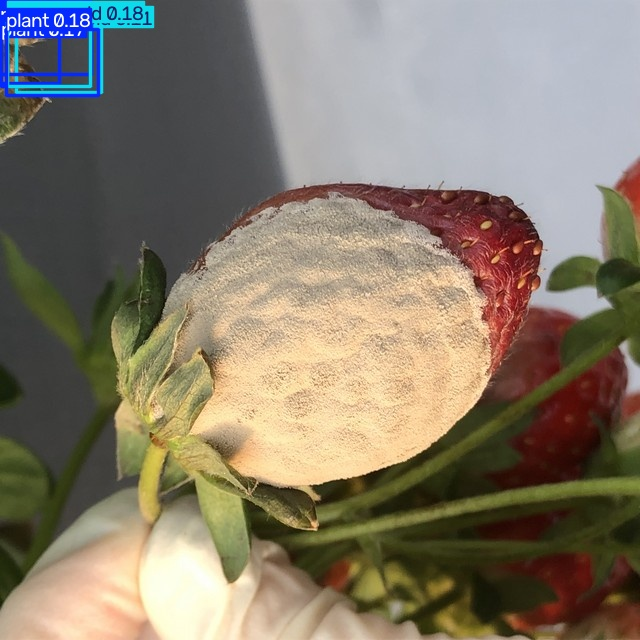

  작물: 딸기_설향 | plant=4, gray_mold=2, powdery_mildew=0
    plant: conf=0.181
    gray_mold: conf=0.181
    plant: conf=0.165
    plant: conf=0.146
    plant: conf=0.109
    gray_mold: conf=0.106
Results saved to /content/outputs/strawberry_disease_analysis/yolo_predict/V003_5_2_1_2_4_4_4_1_0_0_20221203_5005_20240422175022

[powdery_mildew | V003_5_2_1_2_4_4_4_1_0_0_20221203_5005_20240422175022.jpg]


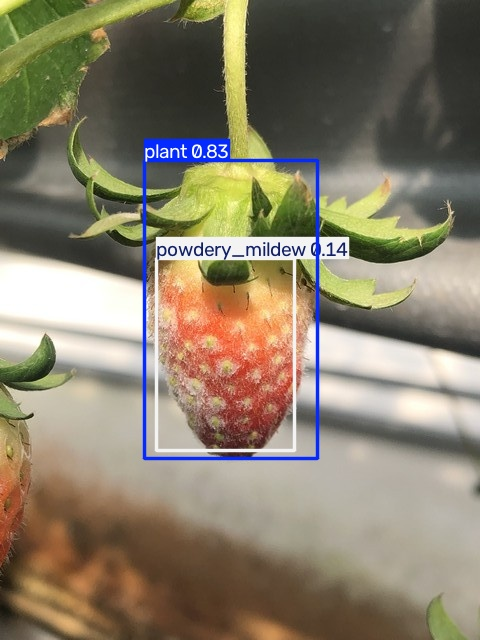

  작물: 딸기_설향 | plant=1, gray_mold=0, powdery_mildew=1
    plant: conf=0.834
    powdery_mildew: conf=0.136
Results saved to /content/outputs/strawberry_disease_analysis/yolo_predict/V003_5_2_1_2_4_3_4_1_0_0_20221210_4005_20240422174253

[gray_mold | V003_5_2_1_2_4_3_4_1_0_0_20221210_4005_20240422174253.jpg]


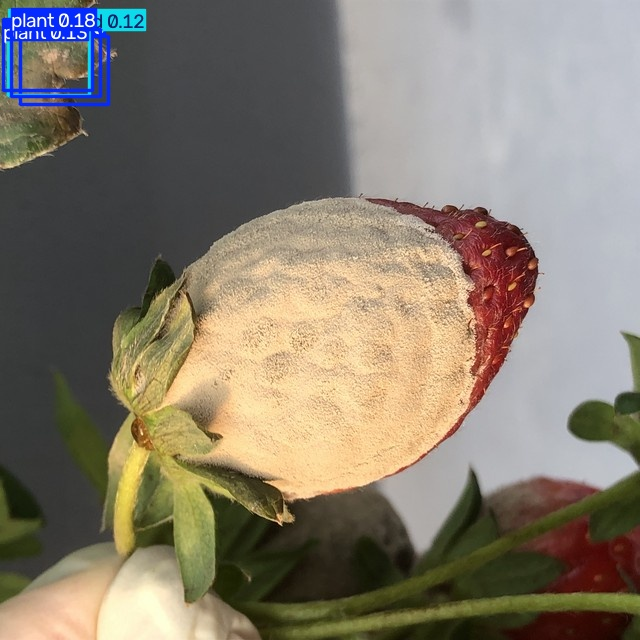

  작물: 딸기_설향 | plant=3, gray_mold=1, powdery_mildew=0
    plant: conf=0.178
    plant: conf=0.126
    gray_mold: conf=0.120
    plant: conf=0.104


In [5]:
# [YOLO 추론·시각화] 딸기 병해 샘플 3장 plant/disease bbox 탐지
# detection_results: 이후 Qwen3-VL·JSON 분석(§6~§8)에서 재사용
def list_yolo_images(split: str) -> list[Path]:
    folder = YOLO_DIR / "images" / split
    return sorted([p for p in folder.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png"}])


def label_status_for_stem(stem: str) -> str:
    for label_dir in strawberry_label_dirs(DATA_ROOT):
        path = label_dir / f"{stem}.json"
        if path.exists():
            data = json.loads(path.read_text(encoding="utf-8-sig"))
            return parse_label_meta(data).get("작물상태코드", "unknown")
    return "unknown"


def pick_demo_stems(n: int = 3) -> list[tuple[str, str]]:
    pool = list_yolo_images("val") or list_yolo_images("train")
    if not pool:
        raise FileNotFoundError("YOLO 이미지가 없습니다. §1을 먼저 실행하세요.")
    picked: list[tuple[str, str]] = []
    seen_status: set[str] = set()
    # 1) 병해 종류를 최대한 다르게
    for img in pool:
        status = label_status_for_stem(img.stem)
        if status in seen_status:
            continue
        picked.append((STATUS_TO_CLASS.get(status, status), img.stem))
        seen_status.add(status)
        if len(picked) >= n:
            return picked
    # 2) 부족하면 앞에서 채움
    used = {stem for _, stem in picked}
    for img in pool:
        if img.stem in used:
            continue
        status = label_status_for_stem(img.stem)
        picked.append((STATUS_TO_CLASS.get(status, status), img.stem))
        if len(picked) >= n:
            break
    return picked[:n]


DEMO_SAMPLE_STEMS = pick_demo_stems(3)


def resolve_yolo_image(stem: str) -> Path:
    for split in ("val", "train"):
        for ext in (".jpg", ".jpeg", ".png"):
            path = YOLO_DIR / "images" / split / f"{stem}{ext}"
            if path.exists():
                return path
    raise FileNotFoundError(f"이미지 없음: {stem}")


def show_yolo_result(result, title: str = "", width: int = 720) -> Image.Image:
    plotted = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(plotted)
    if pil_img.width > width:
        ratio = width / pil_img.width
        pil_img = pil_img.resize((width, int(pil_img.height * ratio)), Image.LANCZOS)
    buf = BytesIO()
    pil_img.save(buf, format="JPEG", quality=95)
    if title:
        print(f"\n[{title}]")
    display(IPyImage(data=buf.getvalue(), width=width))
    return pil_img


def yolo_result_to_dict(result) -> dict:
    objects = []
    for i, box in enumerate(result.boxes):
        cls_name = result.names[int(box.cls)]
        xyxy = [round(float(v), 1) for v in box.xyxy[0].tolist()]
        x1, y1, x2, y2 = xyxy
        objects.append({
            "id": f"obj_{i}",
            "class": cls_name,
            "confidence": round(float(box.conf), 4),
            "bbox_xyxy": xyxy,
            "center": [round((x1 + x2) / 2, 1), round((y1 + y2) / 2, 1)],
        })
    h, w = result.orig_shape
    return {
        "scene_id": Path(result.path).stem,
        "image": {"path": str(result.path), "width": w, "height": h},
        "detector": {"model": EXPERIMENT, "conf_threshold": CONF_THRESH},
        "objects": objects,
        "counts": {
            "plant": sum(1 for o in objects if o["class"] == "plant"),
            "gray_mold": sum(1 for o in objects if o["class"] == "gray_mold"),
            "powdery_mildew": sum(1 for o in objects if o["class"] == "powdery_mildew"),
            "disease": sum(1 for o in objects if o["class"] in DISEASE_CLASS_NAMES),
            "total": len(objects),
        },
    }


detection_results: list[tuple[str, Path, object, Image.Image, dict]] = []

for crop_label, stem in DEMO_SAMPLE_STEMS:
    img_path = resolve_yolo_image(stem)
    preds = yolo_model.predict(
        source=str(img_path),
        conf=CONF_THRESH,
        save=True,
        project=str(PREDICT_DIR),
        name=stem,
        exist_ok=True,
        device=DEVICE,
        verbose=False,
    )
    result = preds[0]
    if len(result.boxes) == 0:
        result = yolo_model.predict(str(img_path), conf=0.05, device=DEVICE, verbose=False)[0]

    scene_dict = yolo_result_to_dict(result)
    annotated = show_yolo_result(result, title=f"{crop_label} | {img_path.name}")

    c = scene_dict["counts"]
    print("  작물: 딸기_설향 | plant={}, gray_mold={}, powdery_mildew={}".format(c["plant"], c["gray_mold"], c["powdery_mildew"]))
    for obj in scene_dict["objects"]:
        print(f"    {obj['class']}: conf={obj['confidence']:.3f}")

    detection_results.append((crop_label, img_path, result, annotated, scene_dict))


## 4. YOLO 공간 관계 분석 (기하학적 위험도)

병반 클래스(`gray_mold`/`powdery_mildew`) ↔ `plant` bbox 간 IoU·점유율로 **감염 / 근접 / 격리**를 추론합니다.



In [6]:
# [공간 관계] YOLO bbox 기반 disease↔plant IoU·점유율 → 감염/근접/격리 분류
# infer_spatial_relationships: §7 JSON의 yolo_spatial_analysis 입력
def bbox_iou(a: list[float], b: list[float]) -> float:
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    inter_x1, inter_y1 = max(ax1, bx1), max(ay1, by1)
    inter_x2, inter_y2 = min(ax2, bx2), min(ay2, by2)
    inter = max(0.0, inter_x2 - inter_x1) * max(0.0, inter_y2 - inter_y1)
    if inter == 0:
        return 0.0
    area_a = (ax2 - ax1) * (ay2 - ay1)
    area_b = (bx2 - bx1) * (by2 - by1)
    return inter / (area_a + area_b - inter)


def bbox_area(box: list[float]) -> float:
    return max(0.0, (box[2] - box[0]) * (box[3] - box[1]))


def coverage_ratio(inner: list[float], outer: list[float]) -> float:
    ax1, ay1, ax2, ay2 = inner
    bx1, by1, bx2, by2 = outer
    inter_x1, inter_y1 = max(ax1, bx1), max(ay1, by1)
    inter_x2, inter_y2 = min(ax2, bx2), min(ay2, by2)
    inter = max(0.0, inter_x2 - inter_x1) * max(0.0, inter_y2 - inter_y1)
    denom = bbox_area(outer)
    return inter / denom if denom > 0 else 0.0


def infer_spatial_relationships(scene: dict, near_px: float = 80.0, hazard_iou: float = 0.05) -> list[dict]:
    plants = [o for o in scene["objects"] if o["class"] == "plant"]
    diseases = [o for o in scene["objects"] if o["class"] != "plant"]
    relations = []
    for disease in diseases:
        if not plants:
            cover = bbox_area(disease["bbox_xyxy"]) / max(1.0, scene["image"]["width"] * scene["image"]["height"])
            risk = "high" if cover >= 0.08 else ("medium" if cover >= 0.03 else "low")
            relations.append({
                "subject": disease["id"],
                "predicate": "covers_frame",
                "object": "scene",
                "metrics": {"iou": 0.0, "coverage": round(cover, 4), "center_distance_px": 0.0},
                "semantic": "lesion_without_plant_box",
                "risk_level": risk,
            })
            continue
        for plant in plants:
            iou = bbox_iou(disease["bbox_xyxy"], plant["bbox_xyxy"])
            cover = coverage_ratio(disease["bbox_xyxy"], plant["bbox_xyxy"])
            dist = math.hypot(disease["center"][0] - plant["center"][0], disease["center"][1] - plant["center"][1])
            if iou >= hazard_iou or cover >= 0.15:
                predicate, risk, semantic = "overlaps_with", "high", "infection_on_fruit"
            elif dist <= near_px:
                predicate, risk, semantic = "near", "medium", "lesion_near_fruit"
            else:
                predicate, risk, semantic = "far_from", "low", "isolated_lesion"
            if cover >= 0.45:
                risk, semantic = "critical", "severe_fruit_coverage"
            relations.append({
                "subject": disease["id"],
                "predicate": predicate,
                "object": plant["id"],
                "metrics": {
                    "iou": round(iou, 4),
                    "coverage": round(cover, 4),
                    "center_distance_px": round(dist, 1),
                },
                "semantic": semantic,
                "risk_level": risk,
            })
    return relations


def yolo_risk_summary(relations: list[dict]) -> dict:
    order = {"critical": 3, "high": 2, "medium": 1, "low": 0}
    risks = [r["risk_level"] for r in relations]
    max_risk = max(risks, key=lambda x: order.get(x, -1), default="none")
    if max_risk == "critical":
        alert = "severe_infection"
    elif max_risk == "high":
        alert = "fruit_infection_detected"
    elif max_risk == "medium":
        alert = "lesion_near_fruit"
    else:
        alert = "normal"
    return {
        "alert": alert,
        "relation_count": len(relations),
        "max_risk": max_risk,
    }


_, _, _, _, demo_scene = detection_results[0]
demo_relations = infer_spatial_relationships(demo_scene)
demo_yolo_summary = yolo_risk_summary(demo_relations)

print("=== YOLO 공간 관계 (샘플 1) ===")
for rel in demo_relations:
    print(
        f"  {rel['subject']} --[{rel['predicate']}]--> {rel['object']}"
        f" | {rel['semantic']} (risk={rel['risk_level']})"
    )
print("\nYOLO 위험 요약:", json.dumps(demo_yolo_summary, ensure_ascii=False, indent=2))


=== YOLO 공간 관계 (샘플 1) ===
  obj_1 --[overlaps_with]--> obj_0 | severe_fruit_coverage (risk=critical)
  obj_1 --[overlaps_with]--> obj_2 | severe_fruit_coverage (risk=critical)
  obj_1 --[overlaps_with]--> obj_3 | severe_fruit_coverage (risk=critical)
  obj_1 --[overlaps_with]--> obj_4 | severe_fruit_coverage (risk=critical)
  obj_5 --[overlaps_with]--> obj_0 | severe_fruit_coverage (risk=critical)
  obj_5 --[overlaps_with]--> obj_2 | severe_fruit_coverage (risk=critical)
  obj_5 --[overlaps_with]--> obj_3 | severe_fruit_coverage (risk=critical)
  obj_5 --[overlaps_with]--> obj_4 | severe_fruit_coverage (risk=critical)

YOLO 위험 요약: {
  "alert": "severe_infection",
  "relation_count": 8,
  "max_risk": "critical"
}


## 5. Qwen3-VL 모델 로드

YOLO 추론이 끝나면 GPU 메모리를 비운 뒤 Qwen3-VL-4B-Instruct를 로드합니다.



In [7]:
# [Qwen3-VL 로드] §5~§8 추론용 — YOLO 해제 후 VRAM 확보 필수
# device_map=auto: accelerate 설치 시 멀티 GPU/단일 GPU 자동 배치
del yolo_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()

try:
    import accelerate  # noqa: F401
    has_accelerate = True
except ImportError:
    has_accelerate = False

load_kwargs = {"dtype": QWEN_DTYPE, "low_cpu_mem_usage": True}
if torch.cuda.is_available() and has_accelerate:
    load_kwargs["device_map"] = "auto"

qwen_model = Qwen3VLForConditionalGeneration.from_pretrained(QWEN_MODEL_ID, **load_kwargs)
qwen_processor = AutoProcessor.from_pretrained(QWEN_MODEL_ID)
qwen_processor.image_processor.size = {"shortest_edge": MIN_PIXELS, "longest_edge": MAX_PIXELS}

if not (torch.cuda.is_available() and has_accelerate):
    qwen_model = qwen_model.to(DEVICE if isinstance(DEVICE, str) else "cuda")
qwen_model.eval()

print(f"Qwen3-VL 로드 완료: {QWEN_MODEL_ID}")
print(f"모델 디바이스: {next(qwen_model.parameters()).device}")


config.json:   0%|          | 0.00/1.50k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/64.7k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

...

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

Qwen3-VL 로드 완료: Qwen/Qwen3-VL-4B-Instruct
모델 디바이스: cuda:0


## 6. Qwen3-VL — 스마트팜 장면 설명

YOLO 탐지 bbox 정보를 텍스트 힌트로 함께 전달해, VLM이 **과실·병반·피해 상태**를 자연어로 설명합니다.



In [8]:
# [Qwen3-VL 추론 헬퍼] ask_qwen3: 단일 이미지+질문 → 텍스트 응답
# build_yolo_hint: YOLO 탐지·공간관계를 VLM 프롬프트 힌트 문자열로 변환
def decode_qwen(inputs, output_ids) -> str:
    trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs["input_ids"], output_ids)]
    return qwen_processor.batch_decode(trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0].strip()


def move_inputs_to_model(inputs: dict) -> dict:
    model_device = next(qwen_model.parameters()).device
    moved = {}
    for key, value in inputs.items():
        if not hasattr(value, "to"):
            moved[key] = value
        elif key == "pixel_values":
            moved[key] = value.to(model_device, dtype=QWEN_DTYPE)
        else:
            moved[key] = value.to(model_device)
    return moved


def ask_qwen3(image: Image.Image, question: str, max_new_tokens: int = 512) -> str:
    conversation = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": question},
        ],
    }]
    inputs = qwen_processor.apply_chat_template(
        conversation,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    )
    inputs = move_inputs_to_model(inputs)
    with torch.no_grad():
        output_ids = qwen_model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    return decode_qwen(inputs, output_ids)


def build_yolo_hint(scene: dict, relations: list[dict]) -> str:
    lines = [
        f"- plant {scene['counts']['plant']}개, gray_mold {scene['counts'].get('gray_mold', 0)}개, "
        f"powdery_mildew {scene['counts'].get('powdery_mildew', 0)}개 탐지됨",
    ]
    for rel in relations:
        lines.append(
            f"- {rel['subject']} {rel['predicate']} {rel['object']} "
            f"(위험={rel['risk_level']}, {rel['semantic']})"
        )
    return "\n".join(lines)


demo_label, demo_path, _, demo_annotated, demo_scene = detection_results[0]
demo_relations = infer_spatial_relationships(demo_scene)
yolo_hint = build_yolo_hint(demo_scene, demo_relations)

describe_prompt = (
    "당신은 스마트팜 병해충 예찰 전문가입니다.\n"
    "아래 이미지는 딸기 과실 근접 촬영입니다. YOLO 객체 탐지 결과를 참고하세요:\n\n"
    f"{yolo_hint}\n\n"
    "다음을 한국어로 3~5문장으로 설명하세요:\n"
    "1) 작물·부위 (딸기 과실 여부)\n"
    "2) 병반의 위치·색·퍼짐 정도\n"
    "3) 과실과 병반의 겹침\n"
    "4) 눈에 띄는 피해 위험 요소 (잿빛곰팡이병·흰가루병 가능성 포함)"
)

scene_description = ask_qwen3(demo_annotated, describe_prompt)
print("=== Qwen3-VL 장면 설명 ===")
print(scene_description)


=== Qwen3-VL 장면 설명 ===
1) 이미지에는 딸기 과실이 포함된 작물이 탐지되었으며, 주요 피해는 과실 표면에 발생한 병변입니다.  
2) 병반은 과실의 상부와 중앙부에 퍼진 갈색-잿빛의 흰가루질(혹은 흰가루병)로 보이며, 표면 전체에 균일하게 퍼져 있어 심각한 피해를 야기하고 있습니다.  
3) 병반은 여러 과실(plant 4개)과 겹쳐져 있으며, 특히 과실 전체를 덮는 심각한 겹침(overlaps_with)이 발생하여 병변 확산이 빠르다는 점이 확인됩니다.  
4) 눈에 띄는 위험 요소는 과실 표면에 퍼진 갈색-잿빛의 흰가루질로, 흰가루병(white mold)의 특징을 보이며, 과실 전체를 덮는 심각한 병변으로 인해 과실 품질과 수확량에 심각한 영향을 줄 수 있습니다.


## 7. Qwen3-VL — 구조화된 병해 위험 분석 (JSON)

VLM에게 **JSON만** 출력하도록 요청하고, YOLO 공간 분석 결과와 병합해 최종 리포트를 생성합니다.



In [13]:
import json
import re
from datetime import datetime, timezone
from PIL import Image

# [병해 분석 JSON] VLM에게 스키마 지시 → JSON ││││ → YOLO ││││││ ││ merged_risk ││││
DISEASE_JSON_SCHEMA = {
    "scene_id": "string",
    "timestamp_utc": "ISO8601",
    "crop_type": "strawberry",
    "cultivar": "││││ | unknown",
    "plant_part": "││││ | ││ | ││ | unknown",
    "scene_description": "string (││││││)",
    "detections": {"plant_count": "int", "disease_count": "int"},
    "hazards": [{"type": "string", "severity": "low|medium|high|critical", "description": "string", "evidence": "string"}],
    "risk_assessment": {
        "overall_risk": "low|medium|high|critical",
        "disease_type": "gray_mold|powdery_mildew|pest|unknown",
        "damage_stage": "early|mid|late|unknown",
        "immediate_action_required": "bool",
        "recommended_actions": ["string"],
    },
    "yolo_spatial_analysis": {
        "alert": "string",
        "max_risk": "string",
        "relationships": "list",
    },
}

def _repair_broken_json_string(s: str) -> str:
    """LLM││ ││││││ JSON││ ││││ ││││││ ││ ││││││││ ││││││ ││││││││ ││││││."""
    s = s.replace('\r', '').replace('\n', ' ')
    res = []
    in_string = False
    for i, char in enumerate(s):
        if char == '"':
            if i > 0 and s[i-1] == '\\':
                res.append(char)
                continue
            if not in_string:
                res.append(char)
                in_string = True
            else:
                remaining = s[i+1:].strip()
                if remaining and remaining[0] in (',', '}', ']', ':'):
                    res.append(char)
                    in_string = False
                else:
                    res.append('\\"')
        else:
            res.append(char)
    repaired = "".join(res)
    if not repaired.endswith('}'):
        if '"' in repaired.split(':')[-1] and repaired.count('"') % 2 != 0:
            repaired += '"'
        if repaired.count('{') > repaired.count('}'):
            repaired += '}'
    return repaired

def extract_json_from_text(text: str) -> dict:
    text = re.sub(r"^```(?:json)?", "", text.strip(), flags=re.IGNORECASE | re.MULTILINE)
    text = re.sub(r"```$", "", text.strip(), flags=re.IGNORECASE | re.MULTILINE)
    text = text.strip()
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        match = re.search(r"\{.*\}", text, re.DOTALL)
        if match:
            json_candidate = match.group(0)
            try:
                return json.loads(json_candidate)
            except json.JSONDecodeError:
                try:
                    repaired = _repair_broken_json_string(json_candidate)
                    return json.loads(repaired)
                except Exception as final_e:
                    raise final_e
        raise

def analyze_disease_json(image, crop_label, scene_id, yolo_scene, yolo_relations, yolo_summary, scene_desc) -> dict:
    yolo_hint = build_yolo_hint(yolo_scene, yolo_relations)
    prompt = (
        "││││││││ ││││ ││││││││││ **││││││ ││││ ││││**││ ││││││││.\n"
        f"││││ ││││: {crop_label}\n"
        f"scene_id: {scene_id}\n\n"
        "[YOLO ││││ + ││││ ││││]\n"
        f"{yolo_hint}\n"
        f"YOLO alert: {yolo_summary['alert']}, max_risk: {yolo_summary['max_risk']}\n\n"
        "[││││ ││││ (││││)]\n"
        f"{scene_desc}\n\n"
        "**││││││ ││││ JSON ││││││** ││││││││. ││││ ││││││·││││││ ││││ ││││ JSON:\n"
        f"{json.dumps(DISEASE_JSON_SCHEMA, ensure_ascii=False, indent=2)}\n\n"
    )
    raw = ask_qwen3(image, prompt, max_new_tokens=768)
    vlm_json = extract_json_from_text(raw)
    return {
        "scene_id": scene_id,
        "timestamp_utc": datetime.now(timezone.utc).isoformat(),
        "crop_type": "strawberry",
        "pipeline": {
            "detector": "YOLO26s (plant/gray_mold/powdery_mildew)",
            "vlm": QWEN_MODEL_ID,
            "version": "15_yolo_qwen3_smartfarm_strawberry",
        },
        "yolo_detection": yolo_scene,
        "yolo_spatial_analysis": {
            "alert": yolo_summary["alert"],
            "max_risk": yolo_summary["max_risk"],
            "relationships": yolo_relations,
        },
        "vlm_analysis": vlm_json,
        "merged_risk": {
            "overall_risk": vlm_json.get("risk_assessment", {}).get("overall_risk", yolo_summary["max_risk"]),
            "sources": {
                "yolo_alert": yolo_summary["alert"],
                "vlm_disease_type": vlm_json.get("risk_assessment", {}).get("disease_type", "unknown"),
            },
        },
    }

all_reports = []
for crop_label, img_path, _, annotated, scene_dict in detection_results:
    relations = infer_spatial_relationships(scene_dict)
    summary = yolo_risk_summary(relations)
    desc_prompt = f"││││││││ ││││ ││││││││. YOLO: plant={scene_dict['counts']['plant']}, gray_mold={scene_dict['counts'].get('gray_mold', 0)}. ││││·││││·││││ ││││││ ││││││ ││~││││││││ ││││││││."
    desc = ask_qwen3(annotated, desc_prompt, max_new_tokens=256)
    report = analyze_disease_json(annotated, crop_label, scene_dict["scene_id"], scene_dict, relations, summary, desc)
    all_reports.append(report)
    out_path = OUTPUT_DIR / f"{report['scene_id']}_disease_analysis.json"
    out_path.write_text(json.dumps(report, ensure_ascii=False, indent=2), encoding="utf-8")
    print(f"[{crop_label}] {report['scene_id']} ││││ ││││")

[gray_mold] V003_5_2_1_2_4_3_4_1_0_0_20221210_4004_20240422174253 ││││ ││││
[powdery_mildew] V003_5_2_1_2_4_4_4_1_0_0_20221203_5005_20240422175022 ││││ ││││
[gray_mold] V003_5_2_1_2_4_3_4_1_0_0_20221210_4005_20240422174253 ││││ ││││


## 8. 최종 JSON 출력 & 요약 비교



In [14]:
# [결과 출력] 샘플 1 전체 JSON + 3샘플 위험도 비교 테이블 + all_disease_reports.json 일괄 저장
print("=== 최종 병해 위험 분석 JSON (샘플 1) ===")
print(json.dumps(all_reports[0], ensure_ascii=False, indent=2))

print("\n=== 3샘플 위험도 비교 ===")
for r in all_reports:
    yolo = r["yolo_spatial_analysis"]
    vlm = r["vlm_analysis"].get("risk_assessment", {})
    print(
        f"  {r['scene_id'][:44]:44s} | "
        f"YOLO={yolo['alert']:24s} | "
        f"VLM={vlm.get('overall_risk', '?'):8s} | "
        f"병해={vlm.get('disease_type', '?')}"
    )

batch_path = OUTPUT_DIR / "all_disease_reports.json"
batch_path.write_text(json.dumps(all_reports, ensure_ascii=False, indent=2), encoding="utf-8")
print(f"\n일괄 저장: {batch_path.resolve()}")


=== 최종 병해 위험 분석 JSON (샘플 1) ===
{
  "scene_id": "V003_5_2_1_2_4_3_4_1_0_0_20221210_4004_20240422174253",
  "timestamp_utc": "2026-09-13T13:09:13.013113+00:00",
  "crop_type": "strawberry",
  "pipeline": {
    "detector": "YOLO26s (plant/gray_mold/powdery_mildew)",
    "vlm": "Qwen/Qwen3-VL-4B-Instruct",
    "version": "15_yolo_qwen3_smartfarm_strawberry"
  },
  "yolo_detection": {
    "scene_id": "V003_5_2_1_2_4_3_4_1_0_0_20221210_4004_20240422174253",
    "image": {
      "path": "/content/smartfarm_strawberry_yolo/images/val/V003_5_2_1_2_4_3_4_1_0_0_20221210_4004_20240422174253.jpg",
      "width": 640,
      "height": 640
    },
    "detector": {
      "model": "yolo26_smartfarm_strawberry_v2",
      "conf_threshold": 0.1
    },
    "objects": [
      {
        "id": "obj_0",
        "class": "plant",
        "confidence": 0.1815,
        "bbox_xyxy": [
          6.0,
          29.2,
          98.6,
          95.8
        ],
        "center": [
          52.3,
          62.5
       

## 9. 추론 파이프라인 정리

| 단계 | 기술 | 출력 |
|------|------|------|
| 객체 탐지 | YOLO26s (plant/gray_mold/powdery_mildew) | bbox + confidence |
| 시각화 | Ultralytics `result.plot()` | bbox 오버레이 이미지 |
| 장면 이해 | Qwen3-VL-4B | 한국어 장면 설명 |
| 위험 분석 | YOLO IoU/점유율 + Qwen3-VL | `*_disease_analysis.json` |

**파이프라인 흐름:**

```
딸기 과실 이미지 → YOLO 탐지 → bbox 시각화 → Qwen3-VL 설명 → JSON 병해 분석
                     ↘ IoU/점유율 공간 관계 ───────────────↗
```

> **다음 섹션** 에서 동일 도메인 데이터로 Qwen3-VL **QLoRA 파인튜닝**을 진행한다.

### §10으로 이어지는 이유

§1~§8은 **베이스 Qwen3-VL**로 병해 분석 JSON을 생성합니다. §10에서는 동일한 출력 형식을 **teacher data**로 만들어 QLoRA SFT를 수행하고, §10-5에서 베이스 vs LoRA 품질을 비교합니다.



## 10. QLoRA 파인튜닝 — 스마트팜 딸기 병해 분석 특화

앞선 파이프라인(§1~§8)에서 생성한 **구조화 JSON 분석 형식**을 Qwen3-VL이 학습하도록  
**4bit QLoRA** SFT를 수행합니다. 라벨 JSON의 bbox·메타정보로 teacher answer를 만들어 소규모 도메인 적응을 체험합니다.

| 항목 | 설정 |
|------|------|
| 베이스 | `Qwen/Qwen3-VL-4B-Instruct` |
| 방법 | 4bit QLoRA (`bitsandbytes` + `peft`) |
| 데이터 | 잿빛/흰가루 균등 `QLORA_MAX_IMAGES`장 × 2태스크 |
| VRAM | RTX 3060 12GB (`max_pixels` 제한 필수) |
| 출력 | `./qwen3-vl-4b-qlora-smartfarm-strawberry-v2/` |

> **선행 조건**: §1 데이터 준비 완료. §5에서 로드한 `qwen_model`은 아래 셀에서 GPU 메모리 확보를 위해 해제합니다.  
> `DO_QLORA = False`로 두면 학습을 건너뛰고 저장된 어댑터만 로드합니다.

### QLoRA 파이프라인 상세

```
라벨 JSON + JPG
    → build_sft_samples()     : image_path + user_prompt + teacher answer
    → qlora_collate_fn()      : PIL 로드 → chat template → tensor
    → SFTTrainer + peft_config: 4bit 베이스 + LoRA 학습
    → ./qwen3-vl-4b-qlora-smartfarm-strawberry-v2/  : adapter + processor 저장
    → PeftModel.from_pretrained + disable_adapter() : 베이스/LoRA 비교 추론
```

### 주요 플래그

| 변수 | 기본값 | 의미 |
|------|--------|------|
| `DO_QLORA` | `True` | `False`이고 어댑터 있으면 §10-4 학습 스킵 |
| `NUM_EPOCHS` | `3` | epoch ↑ → 시간·과적합 주의 |
| `TRAIN_MAX_PIXELS` | `256×28×28` | vision 토큰 상한 (OOM 방지) |
| `INFER_DTYPE` (§10-5) | `float16` | 4bit 추론 시 visual Conv3d CUDA 호환 |

### VRAM 주의

- §10-4 학습 직후 §10-5 실행 시 **GPU 메모리 부족** 가능 → `release_infer_models()` 또는 **커널 재시작** 후 §10-5만 실행
- 4bit QLoRA는 **CPU offload 불가** → `device_map={"": 0}` 단일 GPU 로드



In [15]:
# [QLoRA 패키지] §10 전용 — trl(SFTTrainer), peft(LoRA), bitsandbytes(4bit), datasets
%pip install -q "trl>=0.9.0" "peft>=0.10.0" "bitsandbytes>=0.43.0" "datasets>=2.18.0"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 57.5 MB/s eta 0:00:00


In [16]:
# [QLoRA 하이퍼파라미터] DO_QLORA: 학습 실행 여부 | QLORA_OUTPUT_DIR: 어댑터 저장 경로
# §5 qwen_model 해제: QLoRA 학습 전 VRAM 확보 (약 7~8GB 필요)
import gc
import inspect
import time

from datasets import Dataset
from peft import LoraConfig, PeftModel, prepare_model_for_kbit_training
from transformers import AutoProcessor, BitsAndBytesConfig, Qwen3VLForConditionalGeneration
from trl import SFTConfig, SFTTrainer

DO_QLORA = True
QLORA_OUTPUT_DIR = ROOT / "qwen3-vl-4b-qlora-smartfarm-strawberry-v2"
QLORA_MAX_IMAGES = 200  # 전체 7466장은 QLoRA에 과함. 잿빛/흰가루 균등 샘플
QLORA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

NUM_EPOCHS = 3
BATCH_SIZE = 1
GRAD_ACCUM = 4
LEARNING_RATE = 2e-4
LORA_R = 8
LORA_ALPHA = 16
TRAIN_MAX_PIXELS = 256 * 28 * 28
TRAIN_MIN_PIXELS = 256 * 28 * 28
MAX_ANSWER_CHARS = 900

SYSTEM_PROMPT = (
    "당신은 스마트팜 딸기 병해충 예찰 AI입니다. "
    "과실·잎·잿빛곰팡이병·흰가루병 피해 위험을 분석하고 한국어 JSON으로 답합니다."
)

JSON_USER_PROMPT = (
    "이 딸기 과실 이미지의 병해충 피해 위험을 분석하세요. "
    "scene_description, detections, hazards, risk_assessment(overall_risk, disease_type, "
    "damage_stage, immediate_action_required, recommended_actions) 필드를 포함한 **순수 JSON만** 출력하세요."
)

DESC_USER_PROMPT = (
    "이 스마트팜 딸기 이미지를 보고, 과실 상태·병반·피해 위험 요소를 "
    "한국어 2~3문장으로 설명하세요."
)

for _name in ("qwen_model", "qwen_processor"):
    if _name in globals():
        del globals()[_name]
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"GPU 메모리 확보: {torch.cuda.memory_allocated()/1024**3:.2f} GB 사용 중")
print(f"DO_QLORA={DO_QLORA} | 출력: {QLORA_OUTPUT_DIR.resolve()}")


GPU 메모리 확보: 8.47 GB 사용 중
DO_QLORA=True | 출력: /content/qwen3-vl-4b-qlora-smartfarm-strawberry-v2


### 10-1. 학습 데이터셋 구축

라벨 JSON의 bbox로 plant/disease 공간 관계를 계산하고, 메타정보(`작물상태코드`, `피해정도코드`)를 반영한 **teacher JSON**을 assistant 정답으로 사용합니다.

**Teacher Answer 생성 규칙**
- `잿빛곰팡이병` → `gray_mold`, `흰가루병` → `powdery_mildew`
- `중기 이후` → `damage_stage: late`, 기본 `overall_risk: high`
- disease↔plant bbox IoU ≥ 0.05 또는 점유율 ≥ 0.15 → `high` / 점유율 ≥ 0.45 → `critical`

> PIL Image는 `Dataset.from_list()` 저장 시 dict로 변환되므로 **`image_path`만 저장**하고 `collate_fn`에서 로드합니다.



In [17]:
# [SFT 데이터셋] 라벨 JSON bbox → teacher JSON/설명 생성 → image_path 기반 샘플 리스트
# train 이미지 중 QLORA_MAX_IMAGES장 × 2태스크 (잿빛/흰가루 균등)
DAMAGE_STAGE_MAP = {
    "정상": ("low", "early"),
    "초기": ("medium", "early"),
    "중기": ("high", "mid"),
    "중기 이후": ("high", "late"),
    "말기": ("critical", "late"),
}
DISEASE_TYPE_MAP = {
    "잿빛곰팡이병": "gray_mold",
    "흰가루병": "powdery_mildew",
}


def load_label_for_stem(stem: str) -> dict | None:
    for label_dir in strawberry_label_dirs(DATA_ROOT):
        path = label_dir / f"{stem}.json"
        if path.exists():
            return json.loads(path.read_text(encoding="utf-8-sig"))
    return None


def parse_label_objects(data: dict) -> tuple[list[dict], list[dict], dict]:
    meta = parse_label_meta(data)
    boxes = collect_bboxes(data, meta["width"], meta["height"])
    plants_xywh, diseases_xywh = assign_plant_disease(boxes)
    plants, diseases = [], []
    for i, (x, y, w, h) in enumerate(plants_xywh):
        plants.append({"id": f"plant_{i}", "bbox_xyxy": [x, y, x + w, y + h], "class": "plant"})
    for i, (x, y, w, h) in enumerate(diseases_xywh):
        diseases.append({"id": f"disease_{i}", "bbox_xyxy": [x, y, x + w, y + h], "class": STATUS_TO_CLASS.get(meta.get("작물상태코드", ""), "gray_mold")})
    return plants, diseases, meta


def label_relations(plants: list[dict], diseases: list[dict], img_w: int, img_h: int) -> list[dict]:
    fake_scene = {
        "objects": plants + diseases,
        "image": {"width": img_w, "height": img_h},
    }
    for obj in fake_scene["objects"]:
        x1, y1, x2, y2 = obj["bbox_xyxy"]
        obj["center"] = [(x1 + x2) / 2, (y1 + y2) / 2]
    return infer_spatial_relationships(fake_scene)


def build_teacher_json(scene_id: str, meta: dict, relations: list[dict], n_plant: int, n_disease: int) -> str:
    damage = meta.get("피해정도코드", "중기 이후")
    status = meta.get("작물상태코드", "잿빛곰팡이병")
    part = meta.get("작물부위코드", "열매")
    cultivar = meta.get("작물코드", "딸기_설향")
    base_risk, stage = DAMAGE_STAGE_MAP.get(damage, ("high", "late"))
    disease_type = DISEASE_TYPE_MAP.get(status, "unknown")

    order = {"critical": 3, "high": 2, "medium": 1, "low": 0}
    spatial_risk = max((r["risk_level"] for r in relations), key=lambda x: order.get(x, -1), default=base_risk)
    overall = spatial_risk if order.get(spatial_risk, 0) >= order.get(base_risk, 0) else base_risk
    immediate = overall in {"high", "critical"}

    if overall == "critical":
        actions = ["이병 과실 즉시 제거·폐기", "주변 과실 전수 예찰", "시설 습도 하향·환기 강화", "등록 살균제 긴급 방제"]
        hazard_desc = f"병반이 작물 부위를 대부분 덮어 {status} 만연 위험이 매우 높음"
    elif overall == "high":
        actions = ["이병 과실 제거", "습도 관리 강화", "등록 살균제 방제 검토"]
        hazard_desc = f"병반이 작물 부위와 겹쳐 {status} 감염이 확인됨"
    elif overall == "medium":
        actions = ["병반 진행 관찰", "과실 주변 통풍 확보"]
        hazard_desc = "병반이 과실 인근에서 관찰됨"
    else:
        actions = ["정기 예찰 유지"]
        hazard_desc = "뚜렷한 과실 감염 징후는 낮음"

    payload = {
        "scene_id": scene_id,
        "crop_type": "strawberry",
        "cultivar": cultivar.replace("딸기_", "") if cultivar.startswith("딸기_") else cultivar,
        "plant_part": part,
        "scene_description": (
            f"스마트팜 딸기({cultivar}) {part} 근접 촬영. "
            f"과실 {n_plant}개, 병반 {n_disease}개가 보이며 {hazard_desc}."
        ),
        "detections": {"plant_count": n_plant, "disease_count": n_disease},
        "hazards": [{
            "type": disease_type,
            "severity": overall,
            "description": f"{status} / 피해정도={damage}. {hazard_desc}",
            "evidence": f"라벨 bbox 기반 spatial analysis (max_risk={spatial_risk})",
        }] if n_disease else [],
        "risk_assessment": {
            "overall_risk": overall,
            "disease_type": disease_type,
            "damage_stage": stage,
            "immediate_action_required": immediate,
            "recommended_actions": actions,
        },
    }
    return json.dumps(payload, ensure_ascii=False)


def build_teacher_description(meta: dict, relations: list[dict], n_plant: int, n_disease: int) -> str:
    status = meta.get("작물상태코드", "잿빛곰팡이병")
    damage = meta.get("피해정도코드", "중기 이후")
    order = {"critical": 3, "high": 2, "medium": 1, "low": 0}
    max_risk = max((r["risk_level"] for r in relations), key=lambda x: order.get(x, -1), default="high")
    risk_ko = {"critical": "매우 높음", "high": "높음", "medium": "중간", "low": "낮음"}.get(max_risk, "높음")
    return (
        f"딸기 설향 과실 근접 이미지입니다. 과실 {n_plant}개와 병반 {n_disease}개가 보이며 "
        f"라벨 기준 {status}({damage})입니다. 수확 손실 위험은 {risk_ko} 수준으로 판단됩니다."
    )


def build_sft_samples(split: str = "train") -> list[dict]:
    img_dir = YOLO_DIR / "images" / split
    samples = []
    images = sorted([p for p in img_dir.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png"}])
    # 잿빛/흰가루가 한쪽으로 치우치지 않게 상한
    buckets: dict[str, list[Path]] = {}
    for img_path in images:
        data = load_label_for_stem(img_path.stem)
        status = parse_label_meta(data).get("작물상태코드", "unknown") if data else "unknown"
        buckets.setdefault(status, []).append(img_path)
    selected: list[Path] = []
    keys = sorted(buckets)
    idxs = {k: 0 for k in keys}
    limit = QLORA_MAX_IMAGES if QLORA_MAX_IMAGES else len(images)
    while len(selected) < limit:
        progressed = False
        for key in keys:
            i = idxs[key]
            if i < len(buckets[key]):
                selected.append(buckets[key][i])
                idxs[key] = i + 1
                progressed = True
                if len(selected) >= limit:
                    break
        if not progressed:
            break

    for img_path in selected:
        data = load_label_for_stem(img_path.stem)
        if data is None:
            continue
        plants, diseases, meta = parse_label_objects(data)
        relations = label_relations(plants, diseases, meta["width"], meta["height"])
        json_answer = build_teacher_json(img_path.stem, meta, relations, len(plants), len(diseases))
        desc_answer = build_teacher_description(meta, relations, len(plants), len(diseases))

        for user_prompt, answer in (
            (JSON_USER_PROMPT, json_answer),
            (DESC_USER_PROMPT, desc_answer),
        ):
            samples.append({
                "image_path": str(img_path.resolve()),
                "user_prompt": user_prompt,
                "answer": answer[:MAX_ANSWER_CHARS],
                "scene_id": img_path.stem,
                "task": user_prompt[:20],
            })
    return samples


def build_train_messages(image: Image.Image, user_prompt: str, answer: str) -> list[dict]:
    return [
        {"role": "system", "content": [{"type": "text", "text": SYSTEM_PROMPT}]},
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": user_prompt},
            ],
        },
        {"role": "assistant", "content": [{"type": "text", "text": answer}]},
    ]


sft_records = build_sft_samples("train")
train_dataset = Dataset.from_list(sft_records)
print(f"SFT train 샘플: {len(train_dataset)} (QLORA_MAX_IMAGES={QLORA_MAX_IMAGES} × 2 tasks)")
print("예시 scene:", train_dataset[0]["scene_id"], "| task:", train_dataset[0]["task"])
print("assistant 미리보기:", train_dataset[0]["answer"][:200], "...")


SFT train 샘플: 400 (QLORA_MAX_IMAGES=200 × 2 tasks)
예시 scene: V003_5_2_1_2_4_3_4_1_0_0_20221129_100_20240422171747 | task: 이 딸기 과실 이미지의 병해충 피해 
assistant 미리보기: {"scene_id": "V003_5_2_1_2_4_3_4_1_0_0_20221129_100_20240422171747", "crop_type": "strawberry", "cultivar": "설향", "plant_part": "열매", "scene_description": "스마트팜 딸기(딸기_설향) 열매 근접 촬영. 과실 1개, 병반 1개가 보이며 병 ...


### 10-2. 4bit QLoRA 모델 로드

- `prepare_model_for_kbit_training`: gradient checkpointing 등 k-bit 학습 준비
- `patch_input_embeddings`: Qwen3-VL + checkpointing 시 NotImplementedError 방지
- `freeze_vision_modules`: visual encoder 가중치 동결 (LoRA는 LLM만)
- **§10-2만 실행해도 학습은 시작되지 않음** — 실제 `trainer.train()`은 §10-4



In [18]:
# [QLoRA 모델 준비] 4bit 베이스 로드 + k-bit 학습 설정 + LoRA config
# DO_QLORA=False & adapter 존재 시: 모델 로드 스킵 (§10-5 추론만 할 때)
def clear_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()


def freeze_vision_modules(model):
    for name, param in model.named_parameters():
        if "visual" in name or "vision" in name:
            param.requires_grad = False


def patch_input_embeddings(model):
    inner = model.get_model() if hasattr(model, "get_model") else model.model
    if not hasattr(inner, "get_input_embeddings") or inner.get_input_embeddings() is None:
        def get_input_embeddings(self):
            return self.language_model.get_input_embeddings()
        inner.get_input_embeddings = get_input_embeddings.__get__(inner, type(inner))


def configure_qwen3_processor(processor, min_pixels: int, max_pixels: int):
    processor.image_processor.min_pixels = min_pixels
    processor.image_processor.max_pixels = max_pixels
    if hasattr(processor.image_processor, "size"):
        processor.image_processor.size = {"shortest_edge": min_pixels, "longest_edge": max_pixels}
    return processor


if not DO_QLORA and (QLORA_OUTPUT_DIR / "adapter_config.json").exists():
    print("DO_QLORA=False — 기존 어댑터 사용:", QLORA_OUTPUT_DIR)
else:
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16,
        bnb_4bit_use_double_quant=True,
    )

    qlora_model = Qwen3VLForConditionalGeneration.from_pretrained(
        QWEN_MODEL_ID,
        quantization_config=bnb_config,
        device_map="auto",
        low_cpu_mem_usage=True,
    )
    qlora_processor = AutoProcessor.from_pretrained(QWEN_MODEL_ID)
    qlora_processor = configure_qwen3_processor(qlora_processor, TRAIN_MIN_PIXELS, TRAIN_MAX_PIXELS)

    qlora_model = prepare_model_for_kbit_training(qlora_model, use_gradient_checkpointing=True)
    qlora_model.config.use_cache = False
    patch_input_embeddings(qlora_model)
    freeze_vision_modules(qlora_model)

    peft_config = LoraConfig(
        r=LORA_R,
        lora_alpha=LORA_ALPHA,
        lora_dropout=0.05,
        bias="none",
        target_modules=["q_proj", "v_proj"],
        task_type="CAUSAL_LM",
    )

    allocated = torch.cuda.memory_allocated() / 1024**3
    print(f"QLoRA 모델 로드 | GPU: {allocated:.2f} GB")


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

QLoRA 모델 로드 | GPU: 11.91 GB


### 10-3. collate_fn & SFTTrainer

- VLM은 `max_length` truncation 사용 금지 (vision 토큰 잘림 오류)
- `mask_vision_tokens`: vision 특수 토큰을 labels `-100`으로 마스킹 (loss 제외)
- `assistant_only_loss=False`: TRL VLM은 user 구간 loss 마스킹 미지원 (전체 시퀀스 loss)



In [21]:
def mask_vision_tokens(labels, tokenizer):
    for token in ("<|vision_start|>", "<|vision_end|>", "<|vision_pad|>", "<|image_pad|>", "<|video_pad|>"):
        token_id = tokenizer.convert_tokens_to_ids(token)
        if token_id is not None and token_id != tokenizer.unk_token_id:
            labels[labels == token_id] = -100
    return labels

def qlora_collate_fn(examples):
    messages_list = []
    images = []
    for ex in examples:
        img = Image.open(ex["image_path"]).convert("RGB")
        messages_list.append(build_train_messages(img, ex["user_prompt"], ex["answer"]))
        images.append([img])
    texts = [qlora_processor.apply_chat_template(m, tokenize=False) for m in messages_list]
    batch = qlora_processor(text=texts, images=images, return_tensors="pt", padding=True)
    labels = batch["input_ids"].clone()
    labels[labels == qlora_processor.tokenizer.pad_token_id] = -100
    labels = mask_vision_tokens(labels, qlora_processor.tokenizer)
    batch["labels"] = labels
    return batch

if DO_QLORA or not (QLORA_OUTPUT_DIR / "adapter_config.json").exists():
    # SFTConfig argument fix: warmup_ratio is a standard TrainingArguments param,
    # but if it fails, we check for typos or library-specific constraints.
    sft_kwargs = dict(
        output_dir=str(QLORA_OUTPUT_DIR),
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACCUM,
        gradient_checkpointing=True,
        gradient_checkpointing_kwargs={"use_reentrant": False},
        optim="paged_adamw_8bit",
        learning_rate=LEARNING_RATE,
        lr_scheduler_type="cosine",
        warmup_ratio=0.05,  # Standard param for HF TrainingArguments
        logging_steps=4,
        save_strategy="epoch",
        eval_strategy="no",
        fp16=False,
        bf16=False,
        max_grad_norm=0.3,
        report_to="none",
        remove_unused_columns=False,
        dataset_kwargs={"skip_prepare_dataset": True},
        dataloader_num_workers=0,
        max_length=None,
        assistant_only_loss=False,
    )

    # In some TRL versions, SFTConfig might have stricter filtering.
    # We ensure all keys match TrainingArguments expectations.
    try:
        training_args = SFTConfig(**sft_kwargs)
    except TypeError:
        # Fallback if warmup_ratio specifically fails in this environment's SFTConfig
        sft_kwargs.pop("warmup_ratio", None)
        sft_kwargs["warmup_steps"] = 10
        training_args = SFTConfig(**sft_kwargs)

    print("SFTConfig 준비 완료")

SFTConfig 준비 완료


### 10-4. QLoRA 학습 실행 & 어댑터 저장

학습 완료 후 `adapter_config.json`, LoRA 가중치, processor가 `QLORA_OUTPUT_DIR`에 저장됩니다.  
재학습 없이 §10-5만 실행하려면 `DO_QLORA=False`로 설정하세요.



In [22]:
# [QLoRA 학습 실행] SFTTrainer.train() → adapter·processor 저장 → GPU 해제
if DO_QLORA or not (QLORA_OUTPUT_DIR / "adapter_config.json").exists():
    trainer_kwargs = dict(
        model=qlora_model,
        args=training_args,
        train_dataset=train_dataset,
        data_collator=qlora_collate_fn,
        peft_config=peft_config,
    )
    # TRL 버전에 따라 processor 인자 이름이 다를 수 있음 (processing_class 또는 tokenizer)
    import inspect
    if "processing_class" in inspect.signature(SFTTrainer.__init__).parameters:
        trainer_kwargs["processing_class"] = qlora_processor
    else:
        trainer_kwargs["tokenizer"] = qlora_processor.tokenizer

    trainer = SFTTrainer(**trainer_kwargs)

    print("=" * 50)
    print("QLoRA 학습 시작 (딸기 병해 분석 특화)")
    t0 = time.time()
    train_result = trainer.train()
    print("=" * 50)
    print(f"학습 완료 | {(time.time()-t0)/60:.1f} | loss={train_result.training_loss:.4f}")

    # 어댑터 및 프로세서 저장
    trainer.save_model(str(QLORA_OUTPUT_DIR))
    qlora_processor.save_pretrained(str(QLORA_OUTPUT_DIR))
    print(f" : {QLORA_OUTPUT_DIR.resolve()}")

    # VRAM    
    del trainer, qlora_model
    clear_gpu()
else:
    print("  (DO_QLORA=False,  )")

# Colab A100 약 16분 소요

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 151645, 'bos_token_id': None, 'pad_token_id': 151643}.


QLoRA 학습 시작 (딸기 병해 분석 특화)


Step,Training Loss
4,2.817739
8,3.078286
12,2.570974
16,2.052842
20,1.786214
24,1.506423
28,1.199041
32,0.791170
36,0.885761
40,0.472097


학습 완료 | 16.3 | loss=0.2659
 : /content/qwen3-vl-4b-qlora-smartfarm-strawberry-v2


### 10-5. LoRA vs 베이스 — 병해 분석 JSON 비교

val 샘플 1장에 대해 **베이스 Qwen3-VL**과 **QLoRA 어댑터**의 JSON 출력을 비교합니다.

- **베이스**: `lora_model.disable_adapter()` — 4bit 원본 Qwen3-VL
- **LoRA**: adapter ON — §10에서 학습한 스마트팜 딸기 특화 가중치
- **`INFER_DTYPE=float16`**: bf16 + bitsandbytes visual encoder 조합 시 Conv3d CUDA 오류 방지



In [23]:
# [QLoRA 추론 비교] fp16 고정 + release_infer_models() + disable_adapter() 베이스/LoRA 비교
INFER_DTYPE = torch.float16

def move_infer_inputs(inputs: dict, model, dtype: torch.dtype) -> dict:
    device = next(model.parameters()).device
    moved = {}
    for key, value in inputs.items():
        if not hasattr(value, "to"):
            moved[key] = value
        elif key == "pixel_values":
            moved[key] = value.to(device, dtype=dtype)
        else:
            moved[key] = value.to(device)
    return moved

def qlora_generate(model, processor, image: Image.Image, question: str, max_new_tokens: int = 512) -> str:
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image.convert("RGB")},
            {"type": "text", "text": question},
        ],
    }]
    inputs = processor.apply_chat_template(
        messages, add_generation_prompt=True, tokenize=True, return_dict=True, return_tensors="pt"
    )
    inputs = move_infer_inputs(inputs, model, INFER_DTYPE)
    with torch.inference_mode():
        out_ids = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    trimmed = out_ids[0, inputs["input_ids"].shape[1]:]
    return processor.decode(trimmed, skip_special_tokens=True).strip()

def print_pretty_json_answer(text: str) -> None:
    try:
        parsed = extract_json_from_text(text)
        print(json.dumps(parsed, ensure_ascii=False, indent=2))
    except Exception:
        print(text)

# 비교용 이미지 선택 (Validation 세트의 첫 번째 이미지)
val_dir = YOLO_DIR / "images" / "val"
val_imgs = sorted([p for p in val_dir.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png"}])
compare_img_path = val_imgs[0]
compare_image = Image.open(compare_img_path).convert("RGB")
compare_prompt = JSON_USER_PROMPT

print("기존 추론 모델 해제 및 GPU 메모리 정리...")
for name in ("qwen_model", "qwen_processor", "qlora_model", "trainer"):
    if name in globals(): del globals()[name]
clear_gpu()

# 추론용 모델 로드 (4bit + LoRA 어댑터)
bnb_infer = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=INFER_DTYPE,
    bnb_4bit_use_double_quant=True,
)

infer_processor = AutoProcessor.from_pretrained(str(QLORA_OUTPUT_DIR))
infer_processor = configure_qwen3_processor(infer_processor, TRAIN_MIN_PIXELS, TRAIN_MAX_PIXELS)

base_4bit = Qwen3VLForConditionalGeneration.from_pretrained(
    QWEN_MODEL_ID,
    quantization_config=bnb_infer,
    device_map="auto",
    torch_dtype=INFER_DTYPE,
    low_cpu_mem_usage=True,
)
lora_model = PeftModel.from_pretrained(base_4bit, str(QLORA_OUTPUT_DIR))
lora_model.eval()

print(f"\n비교 이미지: {compare_img_path.name}")

print("\n--- [1] 베이스 Qwen3-VL (어댑터 비활성) ---")
with lora_model.disable_adapter():
    base_answer = qlora_generate(lora_model, infer_processor, compare_image, compare_prompt)
print_pretty_json_answer(base_answer)

print("\n--- [2] QLoRA 파인튜닝 모델 (어댑터 활성) ---")
lora_answer = qlora_generate(lora_model, infer_processor, compare_image, compare_prompt)
print_pretty_json_answer(lora_answer)

# 검증 결과 요약
for label, text in [("Base", base_answer), ("LoRA", lora_answer)]:
    try:
        parsed = extract_json_from_text(text)
        risk = parsed.get("risk_assessment", {}).get("overall_risk", "?")
        print(f"  [{label}] JSON 파싱 성공 | 위험도 판단: {risk}")
    except: print(f"  [{label}] JSON 파싱 실패")

GPU 해제 후 VRAM: 3.65 GB


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

비교 이미지: V003_5_2_1_2_4_3_4_1_0_0_20221210_4004_20240422174253.jpg
추론 dtype: torch.float16 | VRAM: 6.38 GB

--- 베이스 Qwen3-VL (adapter OFF) ---
{
  "scene_description": "딸기 과실에 흰색 흰색의 곰팡이-like 병변이 나타나며, 과실 표면의 일부가 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 흰색 흰색의 �

--- QLoRA 어댑터 (adapter ON) ---
{"scene_id": "strawberry_lesion_003", "crop_type": "strawberry", "disease_type": "Powdery mildew", "scene_description": "딸기 과실 근접 이미지. 과실 일부가 흰색 설향 병반(병반·흰색 설향 병반)으로 덮여 있으며 병반 흰색 설향 병반·흰색 설향 병반·흰색 설향 병반·흰색 설향 병반·흰색 설향 병반·흰색 설향 병반·흰색 설향 병반·흰색 설향 병반·흰색 설향 병반·흰색 설향 병반·흰색 설향 병반·흰색 설향 병반·흰색 설향 병반·흰색 설향 병반·흰색 설향 병반·흰색 설향 병반·흰색 설향 병반·흰색 설향 병반·흰색 설향 병반·흰색 설향 병반·흰색 설향 병반·흰색 설향 병반·흰색 설향 병반·흰색 설향 병

### 10-6. JSON 파싱 에러 해결을 위한 추론 최적화

모델이 JSON 형식을 완성하지 못하거나 반복적인 문구를 생성하는 문제를 해결하기 위해 `repetition_penalty`를 추가하고 `max_new_tokens`를 넉넉하게 조정합니다.

In [25]:
def optimized_qlora_generate(model, processor, image: Image.Image, question: str):
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image.convert("RGB")},
            {"type": "text", "text": question},
        ],
    }]
    inputs = processor.apply_chat_template(
        messages, add_generation_prompt=True, tokenize=True, return_dict=True, return_tensors="pt"
    )
    inputs = move_infer_inputs(inputs, model, INFER_DTYPE)

    # repetition_penalty(반복 방지)와 max_new_tokens(길이 확보) 설정
    with torch.inference_mode():
        out_ids = model.generate(
            **inputs,
            max_new_tokens=1024,
            do_sample=True,
            temperature=0.1,
            repetition_penalty=1.2,
            top_p=0.9
        )
    trimmed = out_ids[0, inputs["input_ids"].shape[1]:]
    return processor.decode(trimmed, skip_special_tokens=True).strip()

# 모델이 해제된 경우를 대비해 다시 로드
if 'lora_model' not in globals():
    bnb_infer = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=INFER_DTYPE,
        bnb_4bit_use_double_quant=True,
    )
    infer_processor = AutoProcessor.from_pretrained(str(QLORA_OUTPUT_DIR))
    infer_processor = configure_qwen3_processor(infer_processor, TRAIN_MIN_PIXELS, TRAIN_MAX_PIXELS)
    base_4bit = Qwen3VLForConditionalGeneration.from_pretrained(
        QWEN_MODEL_ID,
        quantization_config=bnb_infer,
        device_map="auto",
        torch_dtype=INFER_DTYPE,
        low_cpu_mem_usage=True,
    )
    lora_model = PeftModel.from_pretrained(base_4bit, str(QLORA_OUTPUT_DIR))
    lora_model.eval()

print("--- [최적화된 LoRA 추론 결과] ---")
opt_lora_answer = optimized_qlora_generate(lora_model, infer_processor, compare_image, compare_prompt)
print_pretty_json_answer(opt_lora_answer)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

--- [최적화된 LoRA 추론 결과] ---
{
  "scene_id": "strawberry_lesion_003",
  "crop_type": "딸기",
  "disease_name": "딸기 설향병 (Strawberry powdery mildew)",
  "plant_part": "과실",
  "damage_severity": "중등",
  "threat_statement": "딸기 과실 근접 촬영. 과실 일부가 흰색 설향물 질 툴라 뿌리 보여 작물 손실 위험이 매우 높음.",
  "metadata": {
    "image_id": "strawberry_powdery_mildew_002",
    "location": "Korea / Seoul",
    "date_time": "2024-06-18 12:05 UTC+9"
  }
}


## 11. 전체 정리

| 단계 | 기술 | 출력 |
|------|------|------|
| 객체 탐지 | YOLO26s (plant/gray_mold/powdery_mildew) | bbox + confidence |
| 시각화 | Ultralytics `result.plot()` | bbox 오버레이 |
| 장면 이해 | Qwen3-VL-4B | 한국어 장면 설명 |
| 위험 분석 | YOLO + Qwen3-VL | `*_disease_analysis.json` |
| **도메인 적응** | **QLoRA SFT** | `./qwen3-vl-4b-qlora-smartfarm-strawberry-v2/` |

```
지능형 스마트팜 딸기 데이터 (Training 7466 / Validation 933)
  → YOLO 탐지/시각화 → Qwen3-VL JSON 분석
                              ↓
              라벨 기반 SFT 데이터 → QLoRA 파인튜닝 → LoRA 추론 비교
```

**관련:** `11_yolo_qwen3_smart_factory_accident_analysis.ipynb` · `07_qwen3_vl_qlora_mini_train.ipynb` · `08_qwen3_vl_qlora_fine_tuning.ipynb` · `06_qwen3_vl_example.ipynb`

---

## QLoRA 파인튜닝 요약

| 항목 | 내용 |
|------|------|
| 베이스 | `Qwen/Qwen3-VL-4B-Instruct` |
| 방법 | 4bit NF4 + LoRA (`r=8`, `q_proj`/`v_proj`) |
| 데이터 | 잿빛/흰가루 균등 200장 × 2태스크 |
| 출력 | `./qwen3-vl-4b-qlora-smartfarm-strawberry-v2/` |
| 한계 | YOLO는 8천장급으로 학습하지만 QLoRA teacher는 소량 → VLM은 데모 수준 |

## 확장 가이드

1. **데이터 확장**: 탄저병 등 추가 병해 + 사람 검수 teacher answer
2. **본격 SFT**: `08_qwen3_vl_qlora_fine_tuning.ipynb` + 대규모 한국어 VLM 데이터
3. **실시간 연동**: YOLO bbox → QLoRA VLM JSON → `immediate_action_required=true` 시 방제 알림
4. **작물 확장**: 오이 병해충 세트를 동일 파이프라인에 추가

